# Green River Mammmoth Cave USGS Gauge Data (Site 03309000) Anlysis of flood events since removal of L&D6 (2018-2026)

In [95]:
## Installing libraries
# Install as needed.

%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install requests

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [96]:
# Import Libraries and print Versions
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np
import os
import sys
import requests
import json

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)
import matplotlib
print("Matplotlib version: ", matplotlib.__version__)
print("Numpy version: ", np.__version__)

print("OS name: ", os.name)
print("Current working directory: ", os.getcwd())
print("Python executable: ", sys.executable)
print("Python path: ", sys.path)
print("Python modules: ", sys.modules)
print("Python platform: ", sys.platform)
print("Python version: ", sys.version)
print("Python version info: ", sys.version_info)



Python version:  3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
Pandas version:  2.2.2
Matplotlib version:  3.9.2
Numpy version:  1.26.4
OS name:  posix
Current working directory:  /Users/raybies/CODE/GreenRiverFerryRiver
Python executable:  /opt/homebrew/anaconda3/bin/python
Python path:  ['/Users/raybies/CODE/GreenRiverFerryRiver', '/opt/homebrew/anaconda3/lib/python312.zip', '/opt/homebrew/anaconda3/lib/python3.12', '/opt/homebrew/anaconda3/lib/python3.12/lib-dynload', '', '/opt/homebrew/anaconda3/lib/python3.12/site-packages', '/opt/homebrew/anaconda3/lib/python3.12/site-packages/aeosa', '/opt/homebrew/anaconda3/lib/python3.12/site-packages/setuptools/_vendor']
Python modules:  {'sys': <module 'sys' (built-in)>, 'builtins': <module 'builtins' (built-in)>, '_frozen_importlib': <module '_frozen_importlib' (frozen)>, '_imp': <module '_imp' (built-in)>, '_thread': <module '_thread' (built-in)>, '_warnings': <module '_warnings' (built-in)>, '_weakref


Download USGS Gauge Data for Green River Mammoth Cave

In [97]:
## USGS Gauge Data
url = 'https://nwis.waterservices.usgs.gov/nwis/iv/?sites=03309000&agencyCd=USGS&startDT=2018-01-01T00:00:00.000-06:00&endDT=2026-02-24T23:59:59.999-05:00&parameterCd=00065&format=rdb'

try: 
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad responses
except requests.exceptions.RequestException as e:
    print(f"Error: {e}")
    # Handle the error appropriately (e.g., log it, retry, etc.)
    exit()

Read the data that is in CSV into a dataframe

In [98]:
from io import StringIO

# Parse the response content and convert it into a DataFrame

# Decode the response content
content = response.content.decode('utf-8')

# Skip comment lines (lines starting with '#') and create a DataFrame
data_lines = "\n".join([line for line in content.splitlines() if not line.startswith('#')])
df = pd.read_csv(StringIO(data_lines), sep='\t')

# Display the first few rows of the DataFrame
print(df.head())

  agency_cd   site_no          datetime tz_cd 220645_00065 220645_00065_cd
0        5s       15s               20d    6s          14n             10s
1      USGS  03309000  2018-01-01 00:00   CST        20.20               A
2      USGS  03309000  2018-01-01 00:15   CST        20.19               A
3      USGS  03309000  2018-01-01 00:30   CST        20.19               A
4      USGS  03309000  2018-01-01 00:45   CST        20.17               A


/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1245403309.py:10: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(data_lines), sep='\t')


Convert data to date time and add new column that converts guage height to elevation

In [99]:
# Rename columns for clarity
df = df.rename(columns={"220645_00065_cd":"approved", "tz_cd":"timezone", "220645_00065":"gage"})

# Remove the first row of the DataFrame
df = df.iloc[1:]

# Reset the index of the DataFrame
df = df.reset_index(drop=True)

# Convert the 'dateTime' column to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['year'] = df['datetime'].dt.year

# Create a new DataFrame with the desired columns       
df2 = df[['datetime', 'gage', 'month', 'day', 'year']]

# Add 'height' column: gage + offset (use offset_ft defined in later cells)
offset_ft = 409.35
df2['height'] = pd.to_numeric(df2['gage'], errors='coerce') + offset_ft

# Display Data to check
df2.head()

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/579613124.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['height'] = pd.to_numeric(df2['gage'], errors='coerce') + offset_ft


,datetime,gage,month,day,year,height
0,2018-01-01 00:00:00,20.20,1,1,2018,429.55
1,2018-01-01 00:15:00,20.19,1,1,2018,429.54
2,2018-01-01 00:30:00,20.19,1,1,2018,429.54
3,2018-01-01 00:45:00,20.17,1,1,2018,429.52
4,2018-01-01 01:00:00,20.15,1,1,2018,429.50


Make a Box Plot of the Max Daily Guage Height, in elevation, for each month.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3961247329.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3961247329.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


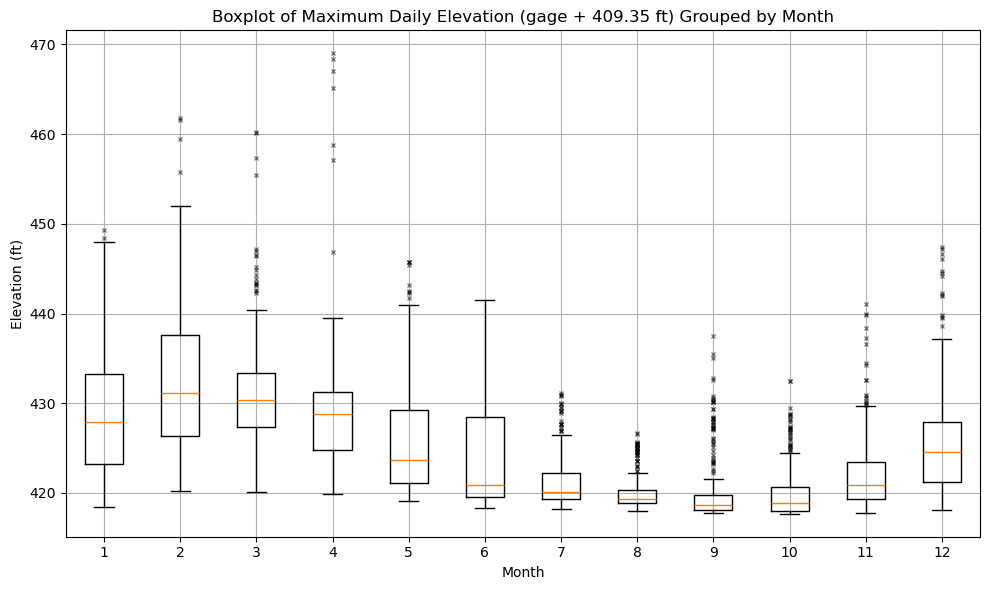

In [100]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['month'] = pd.to_datetime(daily_max_df['date']).dt.month

# Apply vertical offset in feet (convert gage to elevation):
offset_ft = 409.35
daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

# Group the maximum daily elevation by month
grouped_daily_max = daily_max_df.groupby('month')['max_daily_elev_ft']

# Create a boxplot of the maximum daily elevations grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Elevation (gage + 409.35 ft) Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Elevation (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

Make a Box Plot of the Max Daily Guage Height for each month.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3519027179.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3519027179.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


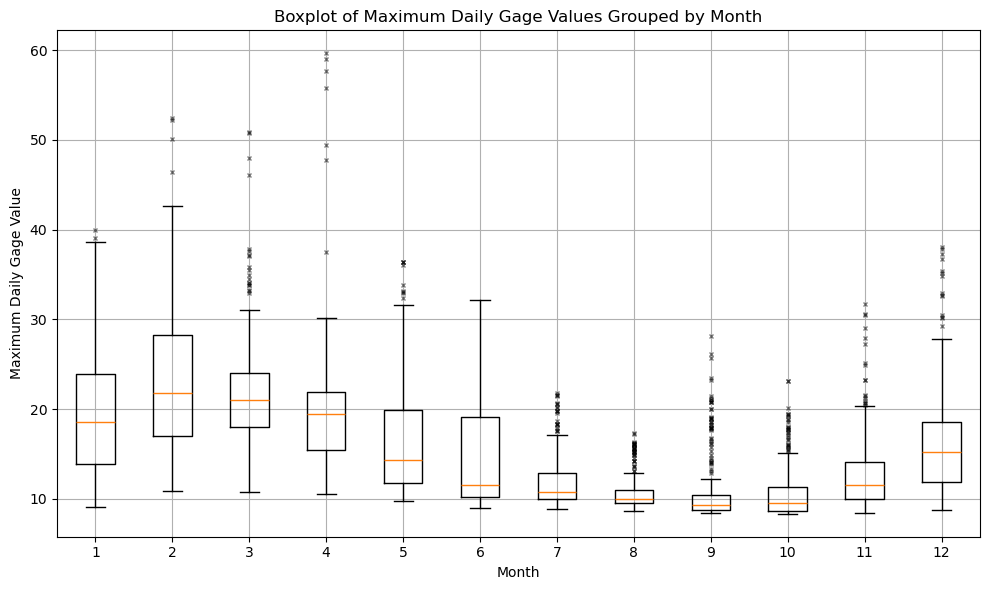

In [101]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['month'] = pd.to_datetime(daily_max_df['date']).dt.month

# Group the maximum daily values by month
grouped_daily_max = daily_max_df.groupby('month')['max_daily_gage']

# Create a boxplot of the maximum daily values grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Gage Values Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Maximum Daily Gage Value')
plt.grid(True)
plt.tight_layout()
plt.show()

Find the number of days each year where the ferry could operate as water guage level was between 9.5 ft and 32 ft. (Note: values based on max guage height for the day, does not reflect days where water may have been too low during normal operating hours but then rose later in day or overnight.)

In [ ]:
# Filter for daily max gauge values between 9.5 and 35 (inclusive)
daily_max_df['gage'] = pd.to_numeric(daily_max_df['max_daily_gage'], errors='coerce')
df_ferry_operable = daily_max_df[daily_max_df['gage'].between(9.5, 35)].copy()

# Add year column
df_ferry_operable['year'] = pd.to_datetime(df_ferry_operable['date']).dt.year

# Count days per year where ferry could operate
ferry_days_by_year = df_ferry_operable.groupby('year').size().reset_index(name='days_operable')

print("Days per year where ferry could operate (gauge between 9.5 and 35 ft):")
print(ferry_days_by_year)

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(ferry_days_by_year['year'], ferry_days_by_year['days_operable'], color='steelblue', edgecolor='black')
plt.title('Number of Days Per Year Ferry Could Operate\n(Gauge Height Between 9.5 and 35 ft)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(ferry_days_by_year['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:

# Count days where the daily max gauge is between 9.5 and 32 (inclusive)

# find appropriate column or build daily_max_df if missing
if 'daily_max_df' in globals() and isinstance(daily_max_df, pd.DataFrame):
    ddf = daily_max_df.copy()
else:
    ddf = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
    ddf.columns = ['date', 'max_daily_gage']

# choose existing gauge column name
for col in ['guage', 'gage', 'max_daily_gage']:
    if col in ddf.columns:
        gauge_col = col
        break
else:
    raise KeyError("No gauge column found in daily_max_df or df.")

# ensure numeric and count
ddf[gauge_col] = pd.to_numeric(ddf[gauge_col], errors='coerce')
count = int(ddf[gauge_col].between(9.5, 32).sum())
print(count)

2445



Box Plot of Guage by year.

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1023957986.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')
/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/1023957986.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


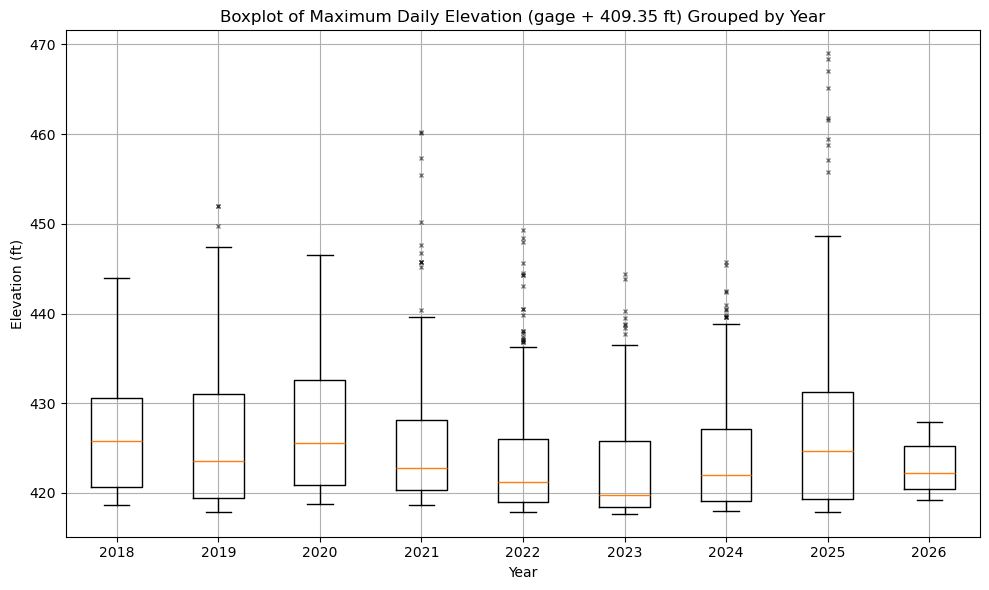

In [103]:
# Ensure the 'gage' column in df is numeric
df['gage'] = pd.to_numeric(df['gage'], errors='coerce')

# Ensure the 'gage' column in df2 is numeric
df2['gage'] = pd.to_numeric(df2['gage'], errors='coerce')

# Create a DataFrame of the maximum gauge value for each day
daily_max_df = df.groupby(df['datetime'].dt.date)['gage'].max().reset_index()
daily_max_df.columns = ['date', 'max_daily_gage']

# Add a month column to the daily_max_df
daily_max_df['year'] = pd.to_datetime(daily_max_df['date']).dt.year

# Apply vertical offset in feet (convert gage to elevation):
offset_ft = 409.35
daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

# Group the maximum daily elevation by month
grouped_daily_max = daily_max_df.groupby('year')['max_daily_elev_ft']

# Create a boxplot of the maximum daily elevations grouped by month
plt.figure(figsize=(10, 6))
plt.boxplot(
    [group for _, group in grouped_daily_max],
    labels=grouped_daily_max.groups.keys(),
    flierprops={
        'marker': 'x',  # Outlier marker symbol
        'markerfacecolor': 'red',  # Outlier marker color
        'markeredgecolor': 'black',  # Outlier marker edge color
        'markersize': 3,  # Outlier marker size
        'alpha': 0.5  # Outlier opacity
    }
)
plt.title('Boxplot of Maximum Daily Elevation (gage + 409.35 ft) Grouped by Year')
plt.xlabel('Year')
plt.ylabel('Elevation (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
print(daily_max_df)

            date  max_daily_gage  year  max_daily_elev_ft
0     2018-01-01           20.20  2018             429.55
1     2018-01-02           18.88  2018             428.23
2     2018-01-03           15.38  2018             424.73
3     2018-01-04           12.58  2018             421.93
4     2018-01-05           11.34  2018             420.69
...          ...             ...   ...                ...
2950  2026-02-20           17.11  2026             426.46
2951  2026-02-21           17.33  2026             426.68
2952  2026-02-22           16.55  2026             425.90
2953  2026-02-23           15.62  2026             424.97
2954  2026-02-24           15.25  2026             424.60

[2955 rows x 4 columns]


Filter Out Events over bottom bridge heights

In [106]:
# Ensure elevation column exists, then filter for >= 477 ft the 500 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_477 = daily_max_df[daily_max_df['max_daily_elev_ft'] >= 477].reset_index(drop=True)

# Check if there is any data to display
if df_477.empty:
    print("No data available: Water elevation never reached 477 feet (the 500 year flood level) in this dataset.")
else:
    # Sort by date to ensure proper sequence detection
    df_477_sorted = df_477.sort_values('date').reset_index(drop=True)

    # Calculate the difference between consecutive dates
    df_477_sorted['date_diff'] = df_477_sorted['date'].diff().dt.days

    # Identify event breaks (where date difference > 1 day)
    df_477_sorted['event_id'] = (df_477_sorted['date_diff'] > 1).cumsum()

    # Count events and days per event
    event_summary_477 = df_477_sorted.groupby('event_id').agg(
        event_start=('date', 'min'),
        event_end=('date', 'max'),
        num_days=('date', 'count'),
        max_elevation=('max_daily_elev_ft', 'max')
    ).reset_index(drop=True)

    # Renumber events starting from 1
    event_summary_477.insert(0, 'event_num', range(1, len(event_summary_477) + 1))

    print(f"Total number of events where water levels is above 477 feet (the 500 year flood mark): {len(event_summary_477)}")
    print(f"\n{event_summary_477}")

    # add a year column so we can group by it
    event_summary_by_year_477 = event_summary_477.copy()
    event_summary_by_year_477['year'] = pd.to_datetime(event_summary_by_year_477['event_start']).dt.year

    # group the event durations by year and make a boxplot
    grouped_year = event_summary_by_year_477.groupby('year')['num_days']

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [grp for _, grp in grouped_year],
        labels=grouped_year.groups.keys(),
        flierprops={'marker': 'x', 'markerfacecolor': 'red',
                    'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
    )
    plt.title('Boxplot of Event Duration (number of days per event) by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Days per Event')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

No data available: Water elevation never reached 477 feet (the 500 year flood level) in this dataset.


In [107]:
# Ensure elevation column exists, then filter for between 470 ft and 477 feet the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_470 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(470,477)].reset_index(drop=True)

# Check if there is any data to display
if df_470.empty:
    print("No data available: Water elevation never reached between 470 and 477 feet in this dataset.")
else:
    # Sort by date to ensure proper sequence detection
    df_470_sorted = df_470.sort_values('date').reset_index(drop=True)

    # Calculate the difference between consecutive dates
    df_470_sorted['date_diff'] = df_470_sorted['date'].diff().dt.days

    # Identify event breaks (where date difference > 1 day)
    df_470_sorted['event_id'] = (df_470_sorted['date_diff'] > 1).cumsum()

    # Count events and days per event
    event_summary_470 = df_470_sorted.groupby('event_id').agg(
        event_start=('date', 'min'),
        event_end=('date', 'max'),
        num_days=('date', 'count'),
        max_elevation=('max_daily_elev_ft', 'max')
    ).reset_index(drop=True)

    # Renumber events starting from 1
    event_summary_470.insert(0, 'event_num', range(1, len(event_summary_470) + 1))

    print(f"Total number of events where water levels is between 470 feet and 477 feet: {len(event_summary_470)}")
    print(f"\n{event_summary_470}")

    # add a year column so we can group by it
    event_summary_by_year_470 = event_summary_470.copy()
    event_summary_by_year_470['year'] = pd.to_datetime(event_summary_by_year_470['event_start']).dt.year

    # group the event durations by year and make a boxplot
    grouped_year = event_summary_by_year_470.groupby('year')['num_days']

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [grp for _, grp in grouped_year],
        labels=grouped_year.groups.keys(),
        flierprops={'marker': 'x', 'markerfacecolor': 'red',
                    'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
    )
    plt.title('Boxplot of Event Duration (number of days per event) by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Days per Event')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

No data available: Water elevation never reached between 470 and 477 feet in this dataset.


Total number of events where water levels is between 450 feet and 470 feet (the 100 year flood mark): 4

   event_num event_start   event_end  num_days  max_elevation
0          1  2019-02-25  2019-02-26         2         451.97
1          2  2021-02-28  2021-03-04         5         460.29
2          3  2025-02-16  2025-02-19         4         461.81
3          4  2025-04-04  2025-04-09         6         469.01


/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3920570207.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


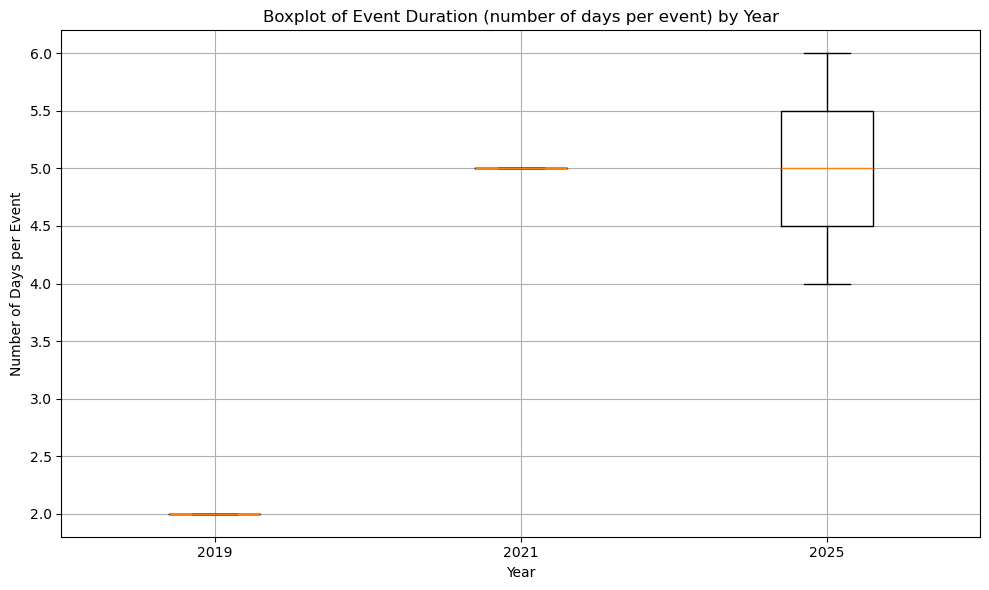

In [112]:
# Ensure elevation column exists, then filter for between 450 ft and 470 feet the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_450 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(450,470)].reset_index(drop=True)


# Sort by date to ensure proper sequence detection
df_450_sorted = df_450.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_450_sorted['date_diff'] = df_450_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_450_sorted['event_id'] = (df_450_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_450 = df_450_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_450.insert(0, 'event_num', range(1, len(event_summary_450) + 1))

print(f"Total number of events where water levels is between 450 feet and 470 feet (the 100 year flood mark): {len(event_summary_450)}")
print(f"\n{event_summary_450}")

# add a year column so we can group by it
event_summary_by_year_450 = event_summary_450.copy()
event_summary_by_year_450['year'] = pd.to_datetime(event_summary_by_year_450['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year_450.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (number of days per event) by Year')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()

Total number of events where water levels is between 435 feet and 450 feet (below the 100 year flood mark): 68

    event_num event_start   event_end  num_days  max_elevation
0           1  2018-02-08  2018-02-09         2         436.71
1           2  2018-02-11  2018-02-13         3         443.95
2           3  2018-02-18  2018-02-19         2         437.62
3           4  2018-02-22  2018-02-27         6         442.97
4           5  2018-03-25  2018-03-26         2         437.44
..        ...         ...         ...       ...            ...
63         64  2025-04-10  2025-04-11         2         446.85
64         65  2025-05-04  2025-05-06         3         438.80
65         66  2025-05-17  2025-05-19         3         443.16
66         67  2025-05-21  2025-05-23         3         441.73
67         68  2025-06-17  2025-06-22         6         441.51

[68 rows x 5 columns]


/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3211397168.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


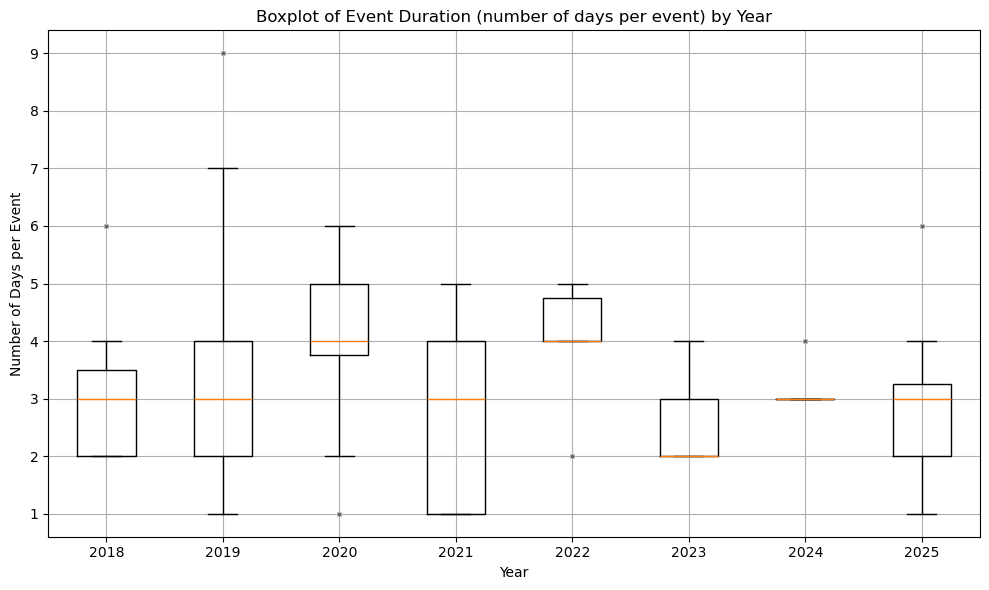

In [109]:
# Ensure elevation column exists, then filter for between 435 ft and 450 feet the 100 year flood level
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_435 = daily_max_df[daily_max_df['max_daily_elev_ft'].between(435,450)].reset_index(drop=True)


# Sort by date to ensure proper sequence detection
df_435_sorted = df_435.sort_values('date').reset_index(drop=True)

# Calculate the difference between consecutive dates
df_435_sorted['date_diff'] = df_435_sorted['date'].diff().dt.days

# Identify event breaks (where date difference > 1 day)
df_435_sorted['event_id'] = (df_435_sorted['date_diff'] > 1).cumsum()

# Count events and days per event
event_summary_435 = df_435_sorted.groupby('event_id').agg(
    event_start=('date', 'min'),
    event_end=('date', 'max'),
    num_days=('date', 'count'),
    max_elevation=('max_daily_elev_ft', 'max')
).reset_index(drop=True)

# Renumber events starting from 1
event_summary_435.insert(0, 'event_num', range(1, len(event_summary_435) + 1))

print(f"Total number of events where water levels is between 435 feet and 450 feet (below the 100 year flood mark): {len(event_summary_435)}")
print(f"\n{event_summary_435}")

# add a year column so we can group by it
event_summary_by_year_435 = event_summary_435.copy()
event_summary_by_year_435['year'] = pd.to_datetime(event_summary_by_year_435['event_start']).dt.year

# group the event durations by year and make a boxplot
grouped_year = event_summary_by_year_435.groupby('year')['num_days']

plt.figure(figsize=(10, 6))
plt.boxplot(
    [grp for _, grp in grouped_year],
    labels=grouped_year.groups.keys(),
    flierprops={'marker': 'x', 'markerfacecolor': 'red',
                'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
)
plt.title('Boxplot of Event Duration (number of days per event) by Year')
plt.xlabel('Year')
plt.ylabel('Number of Days per Event')
plt.grid(True)
plt.tight_layout()
plt.show()

Evalulate the number of flood events with the lenght of the event and max river height durring event.

Total number of events where water levels is above 441 feet: 34

    event_num event_start   event_end  num_days  max_elevation
0           1  2018-02-11  2018-02-13         3         443.95
1           2  2018-02-22  2018-02-23         2         442.97
2           3  2018-02-25  2018-02-26         2         441.73
3           4  2018-03-30  2018-03-31         2         443.23
4           5  2018-11-16  2018-11-16         1         441.09
5           6  2018-12-02  2018-12-03         2         442.04
6           7  2019-01-01  2019-01-02         2         443.89
7           8  2019-02-08  2019-02-09         2         443.48
8           9  2019-02-12  2019-02-14         3         446.42
9          10  2019-02-21  2019-02-27         7         451.97
10         11  2019-12-01  2019-12-03         3         446.60
11         12  2019-12-17  2019-12-19         3         447.39
12         13  2019-12-30  2020-01-01         3         444.74
13         14  2020-02-05  2020-02-07         3      

/var/folders/vj/vdrtmr891czclg0wttpr4h2h0000gn/T/ipykernel_11302/3491286932.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


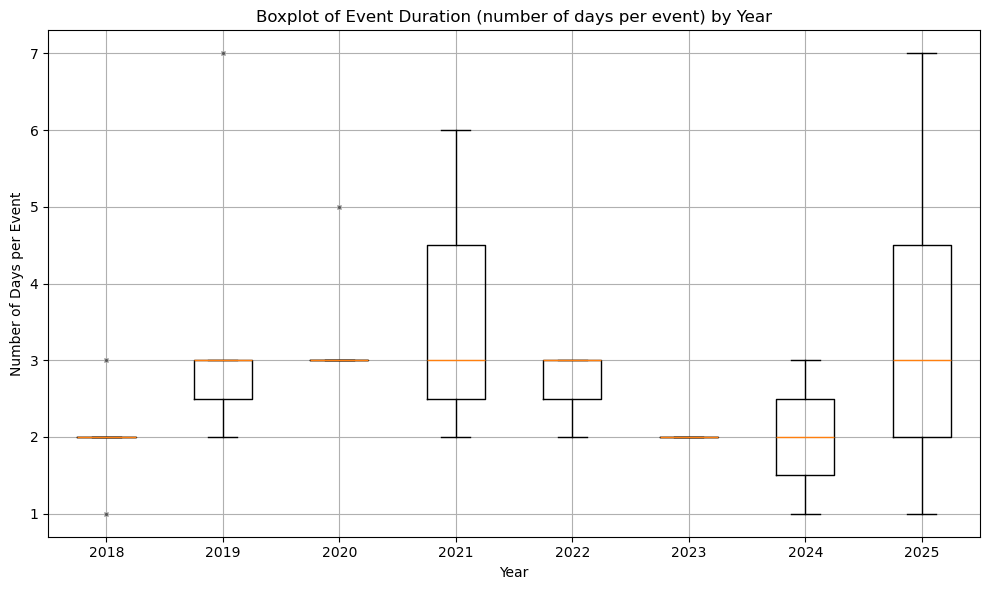

In [110]:
# Box plot of days were river was above 441 ft, the elevation where gauge is 35 feet.
# Ensure elevation column exists, then filter for >= 441 feet
if 'max_daily_elev_ft' not in daily_max_df.columns:
    daily_max_df['max_daily_elev_ft'] = daily_max_df['max_daily_gage'] + offset_ft

df_441 = daily_max_df[daily_max_df['max_daily_elev_ft']>= 441].reset_index(drop=True)

# Check if there is any data to display
if df_441.empty:
    print("No data available: Water elevation never reached 441 feet in this dataset.")
else:
    # Sort by date to ensure proper sequence detection
    df_441_sorted = df_441.sort_values('date').reset_index(drop=True)

    # Calculate the difference between consecutive dates
    df_441_sorted['date_diff'] = df_441_sorted['date'].diff().dt.days

    # Identify event breaks (where date difference > 1 day)
    df_441_sorted['event_id'] = (df_441_sorted['date_diff'] > 1).cumsum()

    # Count events and days per event
    event_summary_441 = df_441_sorted.groupby('event_id').agg(
        event_start=('date', 'min'),
        event_end=('date', 'max'),
        num_days=('date', 'count'),
        max_elevation=('max_daily_elev_ft', 'max')
    ).reset_index(drop=True)

    # Renumber events starting from 1
    event_summary_441.insert(0, 'event_num', range(1, len(event_summary_441) + 1))

    print(f"Total number of events where water levels is above 441 feet: {len(event_summary_441)}")
    print(f"\n{event_summary_441}")

    # add a year column so we can group by it
    event_summary_by_year_441 = event_summary_441.copy()
    event_summary_by_year_441['year'] = pd.to_datetime(event_summary_by_year_441['event_start']).dt.year

    # group the event durations by year and make a boxplot
    grouped_year = event_summary_by_year_441.groupby('year')['num_days']

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [grp for _, grp in grouped_year],
        labels=grouped_year.groups.keys(),
        flierprops={'marker': 'x', 'markerfacecolor': 'red',
                    'markeredgecolor': 'black', 'markersize': 3, 'alpha': 0.5}
    )
    plt.title('Boxplot of Event Duration (number of days per event) by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Days per Event')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

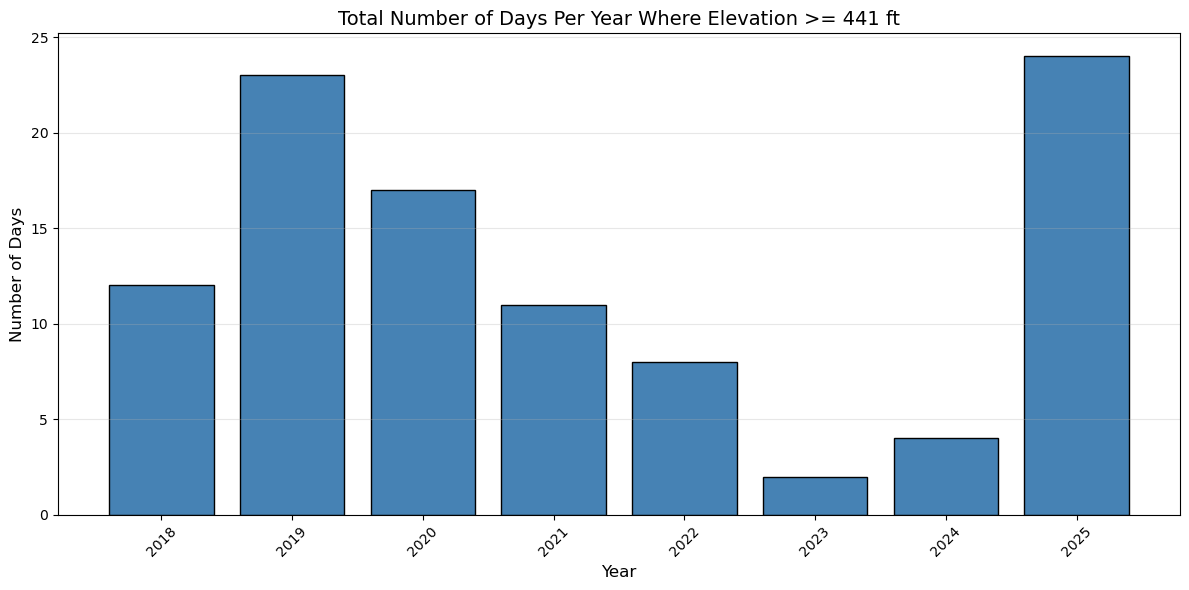

In [114]:
# Create a simple bar chart of the number of days per year where daily max elevation >= 441 ft
days_per_year_441 = event_summary_by_year_441.groupby('year')['num_days'].sum().reset_index()
days_per_year_441.columns = ['year', 'total_days']

plt.figure(figsize=(12, 6))
plt.bar(days_per_year_441['year'], days_per_year_441['total_days'], color='steelblue', edgecolor='black')
plt.title('Total Number of Days Per Year Where Elevation >= 441 ft', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(days_per_year_441['year'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()